In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import SimpleExpSmoothing


In [2]:
df = pd.read_excel("B.9-SUNSPOT.xlsx" , header = 3)

In [3]:
df

,Year,Sunspot Number,Year.1,Sunspot Number.1,Year.2,Sunspot Number.2,Year.3,Sunspot Number.3,Year.4,Sunspot Number.4
0,1700,5.1,1761,86.0,1822,4.1,1883,63.8,1944,9.7
1,1701,11.1,1762,61.3,1823,1.9,1884,63.6,1945,33.3
2,1702,16.1,1763,45.2,1824,8.6,1885,52.3,1946,92.7
3,1703,23.1,1764,36.5,1825,16.7,1886,25.5,1947,151.7
4,1704,36.1,1765,21.0,1826,36.4,1887,13.2,1948,136.4
...,...,...,...,...,...,...,...,...,...,...
56,1756,10.3,1817,41.1,1878,3.5,1939,88.9,2000,119.7
57,1757,32.5,1818,30.2,1879,6.1,1940,67.9,2001,111.1
58,1758,47.7,1819,24.0,1880,32.4,1941,47.6,2002,104.1
59,1759,54.1,1820,15.7,1881,54.4,1942,30.7,2003,63.8


In [4]:
x_axis = pd.concat([df['Year'], df['Year.1'], df['Year.2'], df['Year.3'], df['Year.4']])
y_axis = pd.concat([df['Sunspot Number'] , df['Sunspot Number.1'] , df['Sunspot Number.2'] ,df['Sunspot Number.3'],df['Sunspot Number.4']])
data = data = pd.DataFrame({'x': x_axis, 'y': y_axis}).sort_values('x')

In [5]:
x = data['x'].astype(int).values 
y = data['y'].values

<function matplotlib.pyplot.show(close=None, block=None)>

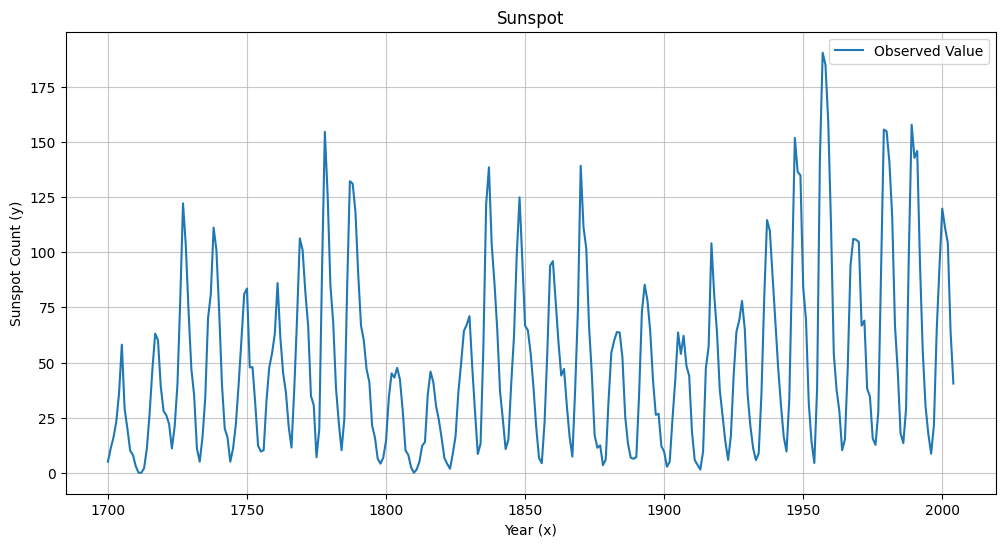

In [6]:
plt.figure(figsize =(12,6))
plt.plot(x , y , label= 'Observed Value')
plt.title('Sunspot')
plt.xlabel('Year (x)')
plt.ylabel('Sunspot Count (y)')
plt.legend()
plt.grid(True , linestyle = '-' , alpha = 0.7)
plt.show

In [7]:
model = SimpleExpSmoothing(data['y'],initialization_method= "estimated")
fitted_model = model.fit(optimized=True)
optimal_smoothing_constant = fitted_model.model.params['smoothing_level']
smoothed_values = fitted_model.fittedvalues
print(f'optimal smoothing constant:{optimal_smoothing_constant}')

optimal smoothing constant:0.9999999850988388


c:\Users\Casper\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [10]:
ts = data['y']
ts.index = data['x']

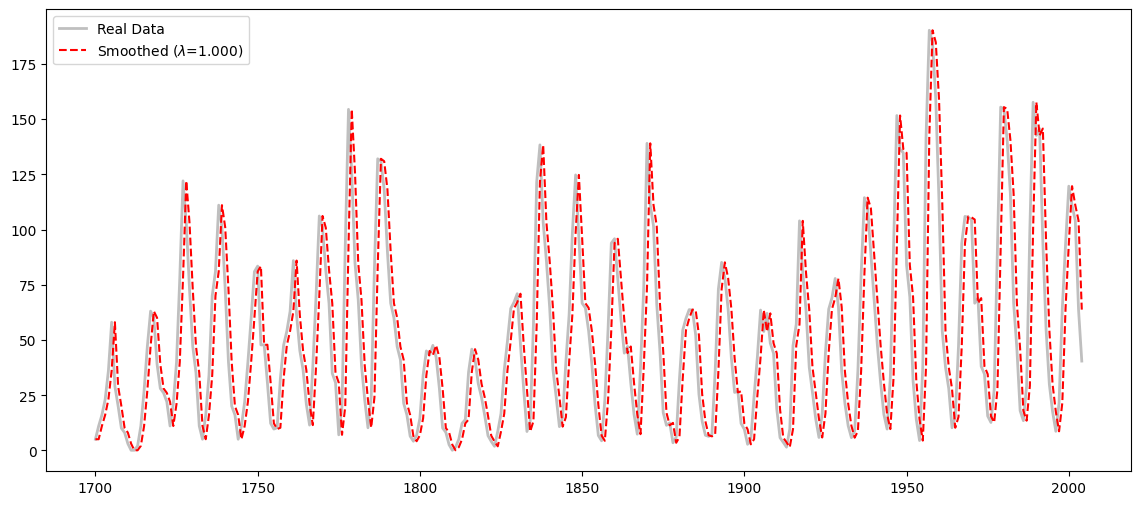

In [12]:
plt.figure(figsize = (14,6))
plt.plot(data['x'], data['y'],label =  'Real Data' , color = 'gray' , alpha = 0.5 , linewidth = 2) #real data
plt.plot(data['x'], smoothed_values, 
         label=f'Smoothed ($\\lambda$={optimal_smoothing_constant:.3f})', 
         color='red', linestyle='--', linewidth=1.5)
plt.legend()
plt.show()